In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.compose import TransformedTargetRegressor

In [2]:
kc_house_data = pd.read_csv('./data/kc_house_data.csv')

In [3]:
kc_house_data.head(5)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


Before building the model, start by looking at a scatterplot of price vs. the square footage of living space. What do you find? How strong does the relationship appear to be?

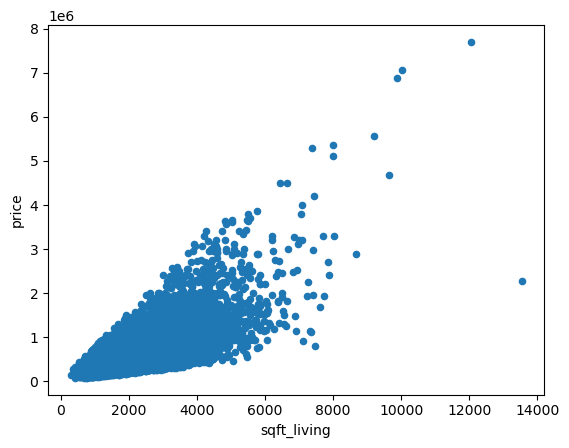

In [4]:
kc_house_data.plot.scatter(x='sqft_living', y='price')

plt.show()

The relationship between home price and square footage of living space is shaped like a funnel. The difference between the minimum and maximum home price increases as the square footage of the living space increases. There is one major outlier that has a high square footage but a comparatively low price. Overall, there is not a strong relationship between square footage of the living space and home price. 

Create a DataFrame, X, which contains one column, the sqft_living space and a Series, y, which contains the target variable.

In [5]:
X = kc_house_data[['sqft_living']]
y = kc_house_data['price']

Use the train_test_split function to create a training and a test set from X and y. Name the resulting pieces X_train, X_test, y_train, and y_test. When you do this, use 30% of the data in the test set. Also, use the random_state parameter so that we can compare model performance as we change the way we build our model.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

Import the LinearRegression class from the linear_model module. Then create a linear regression instance and fit it to the training data.

In [7]:
reg = LinearRegression().fit(X_train, y_train)

What is the intercept term, and what is the coefficient for sqft_living? How can you interpret how the model is using sqft_living to make predictions? Hint: You can get these values by looking at the .intercept_ and .coef_ attributes of the fit model.

In [8]:
reg.intercept_

np.float64(-37893.59850107075)

In [9]:
reg.coef_

array([278.32860644])

The model predicts that each 1-square-foot increase in living space, the home price will increase by $278.

Use the predict method to generate a set of predictions on y_test. Save the results to y_pred. Question: What type of object is y_pred? What is its shape and how does it compare to y_test?

In [10]:
y_pred = reg.predict(X_test)
y_pred

array([ 360116.30871034, 1261900.99358096,  362899.59477476, ...,
        560512.90534826,  374032.73903242,  329500.16200177])

In [11]:
y_pred.shape

(6484,)

In [12]:
y_test.shape

(6484,)

y_pred is a numpy array with 6484 entries (same as y_test).

Calculate mean squared error, root mean squared error, mean absolute error, mean absolute percentage error, and R^2 score on the test set. For each one, interpret what the number means.

In [13]:
mean_squared_error(y_test, y_pred)

70170013932.1159

The MSE indicates that the squared difference between actual home prices and predicted home prices is about 70,170,013,932 squared dollars on average.

In [14]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(264896.23238565685)

The RMSE is more difficult to interpret, although the units are in dollars.

In [15]:
mean_absolute_error(y_test, y_pred)

172604.1288999544

The MAE indicates that our model's home price predictions are off by about $172,604 on average.

In [16]:
mean_absolute_percentage_error(y_test, y_pred)

0.35828223042599716

The MAPE indicates that our model's home price predictions deviate from the actual home prices by an average of 36% of the actual home prices.

In [17]:
r2_score(y_test, y_pred)

0.48889929019453027

The R^2 score is about 0.49, indicating that our model was able to explain 49% of the variation in home prices.

Create a numpy array that is the same length as y_test which just contains a constant value equal to the mean of the target variable on the training data. Hint: you could use the full_like function from numpy to create this array. Does the model using sqft_living do better than this simple baseline model?

In [18]:
y_mean = np.full_like(y_test, y_train.mean())

In [19]:
mean_squared_error(y_test, y_mean)

137294939537.32838

In [20]:
np.sqrt(mean_squared_error(y_test, y_mean))

np.float64(370533.31771559815)

In [21]:
mean_absolute_error(y_test, y_mean)

234538.75986568973

In [22]:
mean_absolute_percentage_error(y_test, y_mean)

0.5371185230836316

In [23]:
r2_score(y_test, y_mean)

-2.1763115412243295e-05

The MSE, RMSE, MAE, and MAPE are all higher for this model, indicating it does a worse job predicting home prices. The R^2 value is also very close to 0, indicating that the model does not help explain any of the variation in home prices from the mean home price (since the mean home price was used to train the model).

Fit a KNeighborsRegressor to the data using just the square footage of living space and using 5 neighbors. How do the metrics compare to those for the linear regression model?

In [24]:
neigh = KNeighborsRegressor(n_neighbors=5)
k_neigh_reg = neigh.fit(X_train, y_train)
y_pred_k_neigh = k_neigh_reg.predict(X_test)

In [25]:
mean_squared_error(y_test, y_pred_k_neigh)

72119466270.09645

In [26]:
np.sqrt(mean_squared_error(y_test, y_pred_k_neigh))

np.float64(268550.67728474725)

In [27]:
mean_absolute_error(y_test, y_pred_k_neigh)

177341.59046884638

In [28]:
mean_absolute_percentage_error(y_test, y_pred_k_neigh)

0.3674572181722411

In [29]:
r2_score(y_test, y_pred_k_neigh)

0.47469997031641686

The K Neighbors Regression model is only slightly worse at predicting home prices than the linear regression model. MSE, RMSE, MAE, and MAPE are all slightly higher, while R^2 is slightly lower.

We can see how the KNN model has more flexibility than the Linear Regression model by plotting their predictions. Create a DataFrame which includes a range of typical square footage values. Hint: you can use the numpy linspace function. Generate 200 equally spaced values between 500 and 3000. Then generate predictions on these using both the linear regression and KNN model. Plot the predictions. What do you notice?

In [30]:
testing = pd.DataFrame({'sqft_living': np.linspace(500, 3000, num=200)})

In [31]:
testing['y_pred_linear'] = reg.predict(testing[['sqft_living']])
testing['y_pred_k_neigh'] = k_neigh_reg.predict(testing[['sqft_living']])

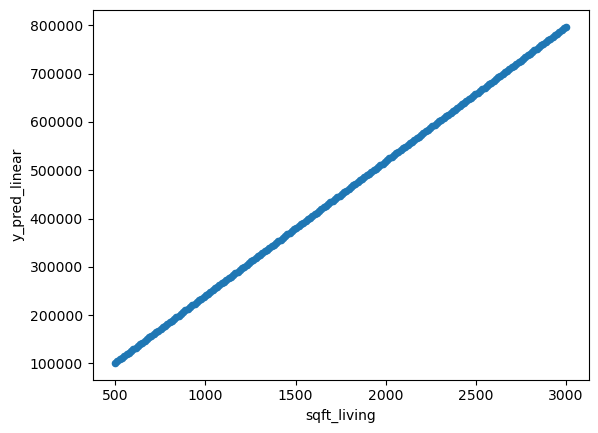

In [32]:
testing.plot.scatter(x='sqft_living', y='y_pred_linear')

plt.show()

testing.plot.scatter(x='sqft_living', y='y_pred_k_neigh')

plt.show()

The predictions of the linear model are very tightly clustered around a line, while the predictions of the K neighbors model are vaguely linear, but much more spread out. 

Finally, let's see what happens when we add another variable. Create a new linear regression model which uses both the square footage of living space and whether or not it is waterfront. When you do this, make sure that you're using the same train and test split by using the same random_state as above. By how much does this improve the model's fit?

In [33]:
X = kc_house_data[['sqft_living', 'waterfront']]
y = kc_house_data['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

reg = LinearRegression().fit(X_train, y_train)

In [34]:
y_pred = reg.predict(X_test)

In [35]:
r2_score(y_test, y_pred)

0.5201149189760734

The R^2 score increases from 0.49 to 0.52 when we add 'waterfront' as another feature in the linear model. This indicates the new model (with both square footage and waterfront features) fits the data better, since it is able to explain more of the variation in home price.

In [36]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(256679.48756207587)

In [37]:
mean_absolute_error(y_test, y_pred)

169406.75838594485

In [38]:
mean_absolute_percentage_error(y_test, y_pred)

0.353138991929231

RMSE and MAE also decrease when we add 'waterfront' as another feature in the linear model, indicating it is a better fit.

One way to add complexity to the model is through using interaction terms. These allow for the relationship between sqft_living and price to differ for waterfront and non-waterfront properties. Create a column containing the product of sqft_living and waterfront. Add this to your model. Does it improve the performance? Interpret the meaning of the coefficients for the model containing the interaction.

In [39]:
X = kc_house_data[['sqft_living', 'waterfront']].copy()
X['interaction'] = X['sqft_living']*X['waterfront']
y = kc_house_data['price']

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

reg = LinearRegression().fit(X_train, y_train)

y_pred = reg.predict(X_test)

r2_score(y_test, y_pred)

0.5415327512713075

In [41]:
mean_absolute_error(y_test, y_pred)

167279.7790160708

In [42]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(250886.15613359137)

In [43]:
mean_absolute_percentage_error(y_test, y_pred)

0.3508118692878629

Adding an interaction increases the R^2 value from 0.52 to 0.54. It decreases MAE, RMSE, and MAPE as well.

In [44]:
reg.intercept_

np.float64(-9494.735578914406)

In [45]:
reg.coef_

array([    261.40828175, -162316.10403125,     308.50992029])

-9494 + 261.4082(sqft_living) - 162316.10(waterfront) + 308.5099(sqft_living)(waterfront)

Interpreting the coefficients: \
For a non-waterfront property, each additional square foot of space increases home price by about \\$261 \
Waterfront properties have an intercept (price of a zero-square foot home) that is \\$162,316.10 lower than the intercept for non-waterfront properties. \
Difference in slope (amount of additional price per square foot) between waterfront and non-waterfront properties is \\$308.5099

Take a look at the distribution of home prices. You'll find that it's highly skewed. When the target is skewed, it can be beneficial to transform the target so that it is closer to normally-distributed in order to reduce the effect of extreme values. Important Note: When comparing metrics for a transformed target and an untransformed target, it is important that you apply an inverse transformation to the predictions from the transformed model. This can be done using a TransformedTargetRegressor. Try using a log transformation on the target. Does this improve the metrics for the model?

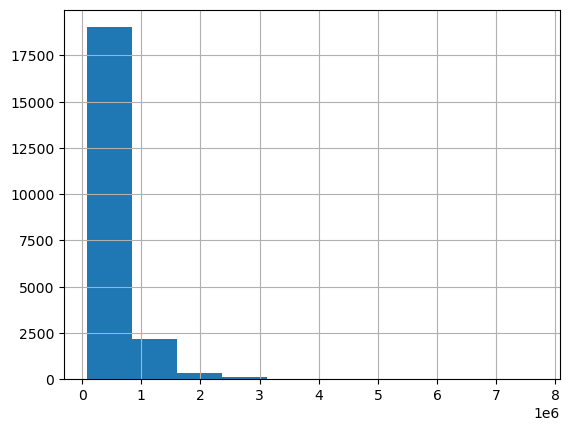

In [46]:
kc_house_data['price'].hist();

In [47]:
X = kc_house_data[['sqft_living', 'waterfront']].copy()
X['interaction'] = X['sqft_living']*X['waterfront']

y = kc_house_data['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

tt = TransformedTargetRegressor(regressor=LinearRegression(),
                                func=np.log, inverse_func=np.exp)

reg = tt.fit(X_train, y_train)

y_pred = tt.predict(X_test)

r2_score(y_test, y_pred)

0.4974494274927064

In [48]:
mean_absolute_error(y_test, y_pred)

162401.76440432313

In [49]:
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(262671.1801772079)

In [50]:
mean_absolute_percentage_error(y_test, y_pred)

0.31771925292163095

Applying a log transformation to home prices lowered R^2 from 0.54 to 0.50, indicating our model accounts for less of the variation in home prices. It lowers MAE and MAPE, but increases RMSE.